In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/meal_demand_historical.csv")

In [3]:
df.head()

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type
0,1,136.83,152.29,0,0,177,2.0,Brackenbury,Mushroom Stew,Vegetarian,main
1,1,136.83,135.83,0,0,270,2.0,Brackenbury,Dwarven Meat Pie,Meat,main
2,1,134.86,135.86,0,0,189,2.0,Brackenbury,Dragonfire Chili,Meat,main
3,1,339.50,437.53,0,0,54,2.0,Brackenbury,Stuffed Mushrooms,Vegetarian,starter
4,1,243.50,242.50,0,0,40,2.0,Brackenbury,Grilled Trout with Lemon,Seafood,main


### Checking the datatypes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   week_number            456548 non-null  int64  
 1   checkout_price         456548 non-null  float64
 2   base_price             456548 non-null  float64
 3   emailer_for_promotion  456548 non-null  int64  
 4   homepage_featured      456548 non-null  int64  
 5   num_orders             456534 non-null  object 
 6   op_area                456548 non-null  float64
 7   city_name              456548 non-null  object 
 8   meal_name              456548 non-null  object 
 9   meal_category          456548 non-null  object 
 10  meal_type              456548 non-null  object 
dtypes: float64(3), int64(3), object(5)
memory usage: 38.3+ MB


### Checking the columns

In [7]:
df.columns

Index(['week_number', 'checkout_price', 'base_price', 'emailer_for_promotion',
       'homepage_featured', 'num_orders', 'op_area', 'city_name', 'meal_name',
       'meal_category', 'meal_type'],
      dtype='object')

### num_orders which is supposed to be the target variable, it's datatype needs to be 'int', but in the data, it shows object type. 

In [9]:
pd.to_numeric?

Signature:
pd.to_numeric(
    arg,
    errors: 'DateTimeErrorChoices' = 'raise',
    downcast: "Literal['integer', 'signed', 'unsigned', 'float'] | None" = None,
    dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>,
)
Docstring:
Convert argument to a numeric type.

The default return dtype is `float64` or `int64`
depending on the data supplied. Use the `downcast` parameter
to obtain other dtypes.

Please note that precision loss may occur if really large numbers
are passed in. Due to the internal limitations of `ndarray`, if
numbers smaller than `-9223372036854775808` (np.iinfo(np.int64).min)
or larger than `18446744073709551615` (np.iinfo(np.uint64).max) are
passed in, it is very likely they will be converted to float so that
they can be stored in an `ndarray`. These warnings apply similarly to
`Series` since it internally leverages `ndarray`.

Parameters
----------
arg : scalar, list, tuple, 1-d array, or Series
    Argument to be converted.
errors : {'ignore', 'raise', '

### we couldn't convert the target variable to integer as it contains some impurities.

### Studying the null values

In [12]:
nulls = df['num_orders'].isnull()

In [13]:
df.groupby?

Signature:
df.groupby(
    by=None,
    axis: 'Axis | lib.NoDefault' = <no_default>,
    level: 'IndexLabel | None' = None,
    as_index: 'bool' = True,
    sort: 'bool' = True,
    group_keys: 'bool' = True,
    observed: 'bool | lib.NoDefault' = <no_default>,
    dropna: 'bool' = True,
) -> 'DataFrameGroupBy'
Docstring:
Group DataFrame using a mapper or by a Series of columns.

A groupby operation involves some combination of splitting the
object, applying a function, and combining the results. This can be
used to group large amounts of data and compute operations on these
groups.

Parameters
----------
by : mapping, function, label, pd.Grouper or list of such
    Used to determine the groups for the groupby.
    If ``by`` is a function, it's called on each value of the object's
    index. If a dict or Series is passed, the Series or dict VALUES
    will be used to determine the groups (the Series' values are first
    aligned; see ``.align()`` method). If a list or ndarray of length

### Let's see if there is any relation between any of the columns and null values

In [15]:
df[nulls].groupby('week_number').size()

week_number
19     1
24     1
38     1
47     1
70     1
72     1
80     1
84     1
90     1
91     1
104    1
123    1
132    1
145    1
dtype: int64

In [16]:
df.columns

Index(['week_number', 'checkout_price', 'base_price', 'emailer_for_promotion',
       'homepage_featured', 'num_orders', 'op_area', 'city_name', 'meal_name',
       'meal_category', 'meal_type'],
      dtype='object')

In [17]:
df[nulls].groupby('city_name').size()

city_name
Ashenport       1
Brackenbury     1
Brookhollow     2
Elmswood        1
Jadehaven       1
Nettlefield     1
Northwatch      1
Oakhaven        1
Osprey Point    1
Quagmire        1
Quicksilver     1
Westfall        1
Zarendale       1
dtype: int64

In [18]:
df[nulls].groupby('meal_name').size()

meal_name
Duck Egg Omelette                    1
Dwarven Meat Pie                     1
Elven Salad with Nuts and Berries    1
Fish and Chips                       1
Herb-Crusted Lamb                    1
Honey-Roasted Carrots                3
Oat and Honey Porridge               1
Pumpkin and Sage Gnocchi             1
Salted Pork with Mustard             1
Savory Meat Pies                     2
Wild Boar Ribs                       1
dtype: int64

In [19]:
df[nulls].groupby('meal_category').size()

meal_category
Meat          6
Other         2
Seafood       1
Vegetarian    5
dtype: int64

In [20]:
df[nulls].groupby('meal_type').size()

meal_type
main       8
side       3
starter    3
dtype: int64

In [21]:
df.isnull().sum()

week_number               0
checkout_price            0
base_price                0
emailer_for_promotion     0
homepage_featured         0
num_orders               14
op_area                   0
city_name                 0
meal_name                 0
meal_category             0
meal_type                 0
dtype: int64

In [22]:
df.shape[0] #since we have got nearly half a million rows, the best thing would be to drop the null values

456548

### Removing the nulls from the dataframe and the impurity from the target variable, then convert it into the 'int' datatype

In [24]:
df.num_orders.fillna(method='ffill') # this would fill the null values by using the values above them, because the rows in the data are 
# independent, which implies, they are not associated with the data above or below them. 

/var/folders/xh/dlr59jp10wj5hx57q_rhfy3c0000gn/T/ipykernel_24330/2172617661.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.num_orders.fillna(method='ffill') # this would fill the null values by using the values above them, because the rows in the data are


0         177
1         270
2         189
3          54
4          40
         ... 
456543     68
456544     42
456545    501
456546    729
456547    162
Name: num_orders, Length: 456548, dtype: object

In [25]:
def parse_num_orders(df):
    print(f"Length before parsing num_orders: {len(df)}")
    nulls = df['num_orders'].isnull()
    df = df[~nulls].copy() # this is a business decision as we don't normally do this without consulting the client.
    # instead of just dropping them, we could have performed forward filling for that specific city, meal category or meal type.
    df['num_orders']= df['num_orders'].str.replace(",", "")
    df['num_orders'] = pd.to_numeric(df['num_orders'])
    print(f"Length after parsing num_orders: {len(df)}")
    return df

In [26]:
df = parse_num_orders(df)

Length before parsing num_orders: 456548
Length after parsing num_orders: 456534


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 456534 entries, 0 to 456547
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   week_number            456534 non-null  int64  
 1   checkout_price         456534 non-null  float64
 2   base_price             456534 non-null  float64
 3   emailer_for_promotion  456534 non-null  int64  
 4   homepage_featured      456534 non-null  int64  
 5   num_orders             456534 non-null  int64  
 6   op_area                456534 non-null  float64
 7   city_name              456534 non-null  object 
 8   meal_name              456534 non-null  object 
 9   meal_category          456534 non-null  object 
 10  meal_type              456534 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 41.8+ MB


### Detect anomalies and outliers

In [29]:
df.describe()

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area
count,456534.000000,456534.000000,456534.000000,456534.000000,456534.000000,4.565340e+05,456534.000000
mean,74.768613,332.239431,354.156831,0.081151,0.109199,2.580874e+05,4.083592
std,41.525070,152.940974,160.717508,0.273067,0.311889,4.681222e+06,1.091662
min,1.000000,2.970000,55.350000,0.000000,0.000000,-3.388000e+03,0.900000
25%,39.000000,228.950000,243.500000,0.000000,0.000000,5.400000e+01,3.600000
50%,76.000000,296.820000,310.460000,0.000000,0.000000,1.360000e+02,4.000000
75%,111.000000,445.230000,458.870000,0.000000,0.000000,3.370000e+02,4.500000
max,145.000000,866.270000,866.270000,1.000000,1.000000,1.111000e+09,7.000000


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
week_number,456534.0,74.768613,4.152507e+01,1.00,39.00,76.00,111.00,1.450000e+02
checkout_price,456534.0,332.239431,1.529410e+02,2.97,228.95,296.82,445.23,8.662700e+02
base_price,456534.0,354.156831,1.607175e+02,55.35,243.50,310.46,458.87,8.662700e+02
emailer_for_promotion,456534.0,0.081151,2.730665e-01,0.00,0.00,0.00,0.00,1.000000e+00
homepage_featured,456534.0,0.109199,3.118889e-01,0.00,0.00,0.00,0.00,1.000000e+00
num_orders,456534.0,258087.446749,4.681222e+06,-3388.00,54.00,136.00,337.00,1.111000e+09
op_area,456534.0,4.083592,1.091662e+00,0.90,3.60,4.00,4.50,7.000000e+00


In [31]:
df.week_number.value_counts().sort_index()

week_number
1      2922
2      2896
3      2899
4      2889
5      2859
       ... 
141    3263
142    3238
143    3305
144    3302
145    3267
Name: count, Length: 145, dtype: int64

In [32]:
df.groupby("week_number")['num_orders'].sum()

week_number
1      468587583
2      917277919
3      901885194
4      833935197
5      810990577
         ...    
141    934169797
142    910430534
143    755852213
144    642294484
145    755464243
Name: num_orders, Length: 145, dtype: int64

In [33]:
(df.checkout_price < 0).sum()

np.int64(0)

In [34]:
(df.base_price < 0).sum()

np.int64(0)

In [35]:
(df.num_orders < 0).sum()

np.int64(55)

In [36]:
df[df.num_orders < 0]

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type
6592,3,305.58,306.58,0,0,-528,4.1,Duskbrook,Fish and Chips,Seafood,main
16561,6,447.23,447.23,0,0,-28,3.5,Yewshade,Duck Egg Omelette,Other,starter
25099,9,230.92,292.00,0,0,-216,4.1,Ironforge,Fish and Chips,Seafood,main
33691,12,455.93,456.93,0,0,-14,3.8,Jasperwood,Stuffed Mushrooms,Vegetarian,starter
37698,14,387.03,505.43,0,0,-41,4.0,Oakenspire,Fire-Grilled Venison,Meat,main
43864,16,161.05,233.77,0,0,-297,4.4,Ridgefield,Spiced Apple Tart,Other,dessert
63290,23,161.99,183.33,0,0,-459,2.0,Brackenbury,Beef and Ale Stew,Meat,main
84459,30,233.83,231.83,0,0,-80,3.8,Moonshadow,Salted Pork with Mustard,Meat,main
104609,36,281.33,281.33,0,0,-188,7.0,Stormwatch,Elven Salad with Nuts and Berries,Vegetarian,starter
108369,37,670.33,669.33,0,0,-80,3.9,Amberhill,Honey Mead,Other,beverage


<Axes: >

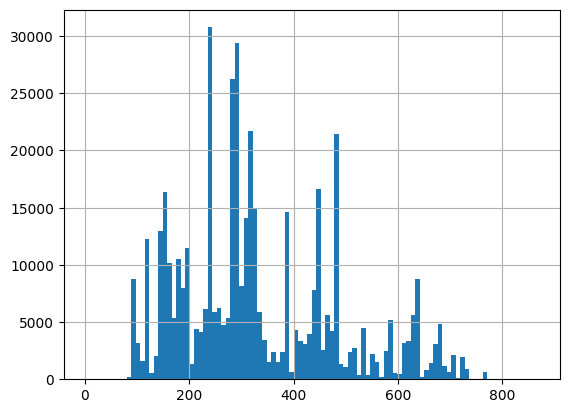

In [37]:
df['checkout_price'].hist(bins=100)

<Axes: >

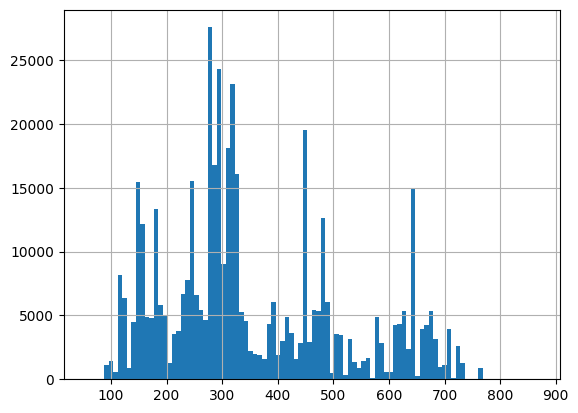

In [38]:
df['base_price'].hist(bins=100)

<Axes: >

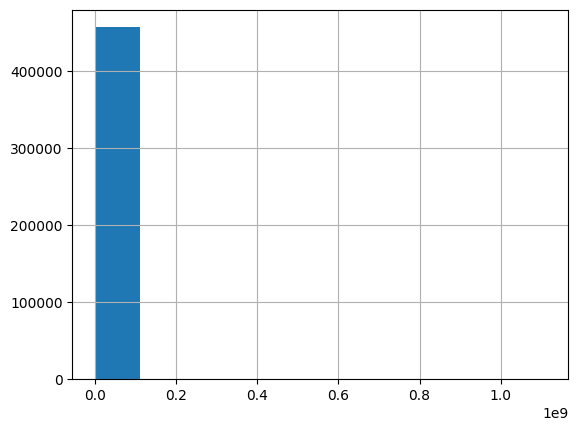

In [39]:
df['num_orders'].hist()

/Users/Faheem/Documents/Projects/Demand Forecasting/demand_forecasting_venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

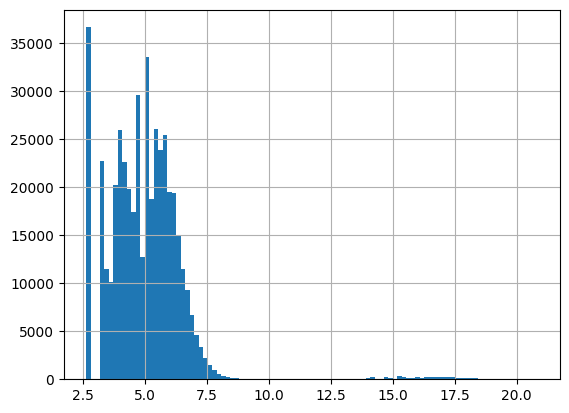

In [40]:
np.log1p(df['num_orders']).hist(bins=100)

In [41]:
df['num_orders'].value_counts().sort_values(ascending=False)

num_orders
13           12268
15           12172
14           12163
28           11436
26           11348
             ...  
4508             1
136400000        1
5631             1
950              1
89200000         1
Name: count, Length: 1645, dtype: int64

In [42]:
qts = df.quantile([0.05, 0.95], numeric_only=True).T

In [43]:
qts

,0.05,0.95
week_number,8.00,139.00
checkout_price,121.28,640.23
base_price,144.53,668.33
emailer_for_promotion,0.00,1.00
homepage_featured,0.00,1.00
num_orders,14.00,972.00
op_area,2.70,6.70


In [44]:
for col, col_qts in qts.iterrows():
    if col in ('week_number', 'emailer_for_promotion', 'homepage_featured'):
        continue
    print(col)
    print(f"<0.05: threshold: {col_qts.values[0]}")
    print(f"<0.95: threshold: {col_qts.values[1]}")
    print(f"<0.05: threshold: {(df[col] < col_qts.values[0]).sum()}")
    print(f"<0.95: threshold: {(df[col] > col_qts.values[1]).sum()}")
    print(f"<0.05: threshold: {((df[col] < col_qts.values[0]).sum()) / len(df) * 100 }")
    print(f"<0.95: threshold: {((df[col] > col_qts.values[1]).sum()) / len(df) * 100 }")
    print("-----")
    

checkout_price
<0.05: threshold: 121.28
<0.95: threshold: 640.23
<0.05: threshold: 22283
<0.95: threshold: 20827
<0.05: threshold: 4.880907008021309
<0.95: threshold: 4.561982240096028
-----
base_price
<0.05: threshold: 144.53
<0.95: threshold: 668.33
<0.05: threshold: 22174
<0.95: threshold: 22209
<0.05: threshold: 4.857031458774155
<0.95: threshold: 4.864697919541589
-----
num_orders
<0.05: threshold: 14.0
<0.95: threshold: 972.0
<0.05: threshold: 12323
<0.95: threshold: 22715
<0.05: threshold: 2.699251315345626
<0.95: threshold: 4.975533038065072
-----
op_area
<0.05: threshold: 2.7
<0.95: threshold: 6.7
<0.05: threshold: 22045
<0.95: threshold: 20684
<0.05: threshold: 4.828775074802753
<0.95: threshold: 4.530659271817652
-----


In [45]:
qts = df.quantile([0.001, 0.999], numeric_only=True).T

for col, col_qts in qts.iterrows():
    if col in ('week_number', 'emailer_for_promotion', 'homepage_featured'):
        continue
    print(col)
    print(f"<0.001: threshold: {col_qts.values[0]}")
    print(f"<0.999: threshold: {col_qts.values[1]}")
    print(f"<0.001: threshold: {(df[col] < col_qts.values[0]).sum()}")
    print(f"<0.999: threshold: {(df[col] > col_qts.values[1]).sum()}")
    print(f"<0.001: threshold: {((df[col] < col_qts.values[0]).sum()) / len(df) * 100 }")
    print(f"<0.999: threshold: {((df[col] > col_qts.values[1]).sum()) / len(df) * 100 }")
    print("-----")
    

checkout_price
<0.001: threshold: 91.18
<0.999: threshold: 765.33
<0.001: threshold: 392
<0.999: threshold: 440
<0.001: threshold: 0.08586436059526782
<0.999: threshold: 0.09637836393346388
-----
base_price
<0.001: threshold: 94.09
<0.999: threshold: 766.33
<0.001: threshold: 344
<0.999: threshold: 292
<0.001: threshold: 0.07535035725707176
<0.999: threshold: 0.06396018697402603
-----
num_orders
<0.001: threshold: 13.0
<0.999: threshold: 62000000.0
<0.001: threshold: 55
<0.999: threshold: 450
<0.001: threshold: 0.012047295491682986
<0.999: threshold: 0.09856878129558806
-----
op_area
<0.001: threshold: 0.9
<0.999: threshold: 7.0
<0.001: threshold: 0
<0.999: threshold: 0
<0.001: threshold: 0.0
<0.999: threshold: 0.0
-----


In [46]:
df[df['num_orders'] > 62000000.0].num_orders

140        63500000
3130      131100000
3139       76900000
3151       71600000
5674       79800000
            ...    
450293    189000000
452891     82400000
453842     89200000
454345     62100000
455486     75600000
Name: num_orders, Length: 450, dtype: int64

In [47]:
df.quantile([0.25, 0.5, 0.6, 0.7,0.75, 0.8, 0.9, 0.95, 0.99, 0.995, 0.999], numeric_only=True)

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area
0.250,39.0,228.95,243.50,0.0,0.0,54.00,3.6
0.500,76.0,296.82,310.46,0.0,0.0,136.00,4.0
0.600,90.0,323.07,329.86,0.0,0.0,202.00,4.1
0.700,104.0,402.55,438.50,0.0,0.0,283.00,4.4
0.750,111.0,445.23,458.87,0.0,0.0,337.00,4.5
0.800,118.0,466.63,485.03,0.0,0.0,404.00,4.7
0.900,132.0,581.03,630.53,0.0,1.0,647.00,5.3
0.950,139.0,640.23,668.33,1.0,1.0,972.00,6.7
0.990,144.0,708.13,726.53,1.0,1.0,6902.76,7.0
0.995,145.0,727.53,727.53,1.0,1.0,13500000.00,7.0


In [48]:
df.quantile([0.990, 0.991, 0.992, 0.993, 0.994, 0.995, 0.996, 0.997, 0.998, 0.999], numeric_only=True)

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area
0.990,144.0,708.13,726.53,1.0,1.0,6.902760e+03,7.0
0.991,144.0,709.13,726.53,1.0,1.0,2.600000e+06,7.0
0.992,144.0,716.83,726.53,1.0,1.0,4.100000e+06,7.0
0.993,145.0,726.53,727.53,1.0,1.0,6.700000e+06,7.0
0.994,145.0,726.53,727.53,1.0,1.0,9.480200e+06,7.0
0.995,145.0,727.53,727.53,1.0,1.0,1.350000e+07,7.0
0.996,145.0,727.53,728.53,1.0,1.0,1.898680e+07,7.0
0.997,145.0,728.53,728.53,1.0,1.0,2.710000e+07,7.0
0.998,145.0,728.53,738.23,1.0,1.0,3.920000e+07,7.0
0.999,145.0,765.33,766.33,1.0,1.0,6.200000e+07,7.0


### by looking at this, we can clearly say, 0.991 is the point where shit goes south

In [50]:
max_value = 6.902760e+03

<Axes: >

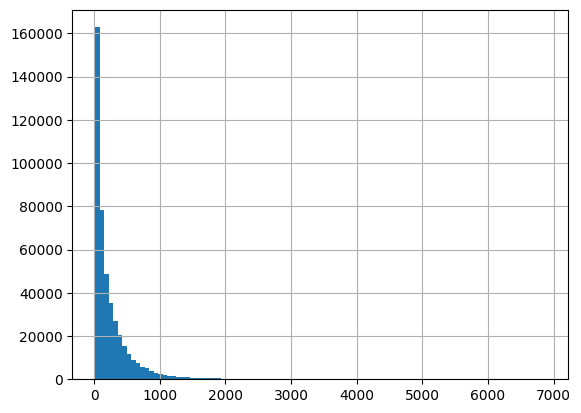

In [51]:
df[(df['num_orders'] >= 0) & (df['num_orders'] < max_value)]['num_orders'].hist(bins=100) ### looks like a gamma distribution

In [52]:
negative_orders = df['num_orders'] < 0
zero_orders = df['num_orders'] == 0 
huge_orders = df['num_orders'] > max_value

def clean_num_orders(df):
    print(f"Length before cleaning num_orders: {len(df)}")
    df = df[~(negative_orders | zero_orders | huge_orders)].copy()
    print(f"Length after cleaning num_orders: {len(df)}")
    return df

df = clean_num_orders(df)

Length before cleaning num_orders: 456534
Length after cleaning num_orders: 451913


<Axes: >

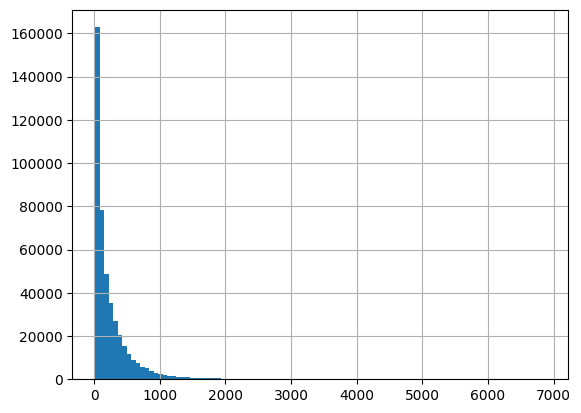

In [53]:
df['num_orders'].hist(bins=100)

### Examine Temporal coverage

<Axes: xlabel='week_number'>

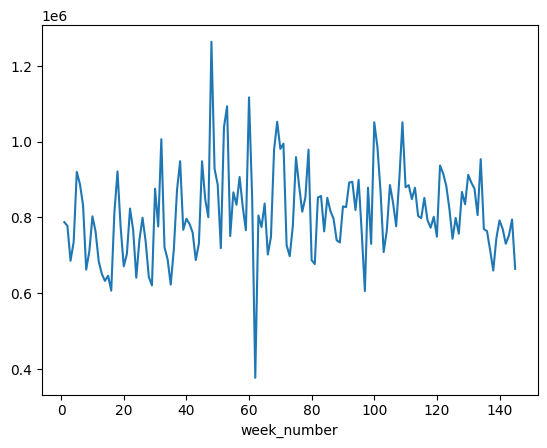

In [55]:
df.groupby("week_number")['num_orders'].sum().plot()

<Axes: xlabel='week_number'>

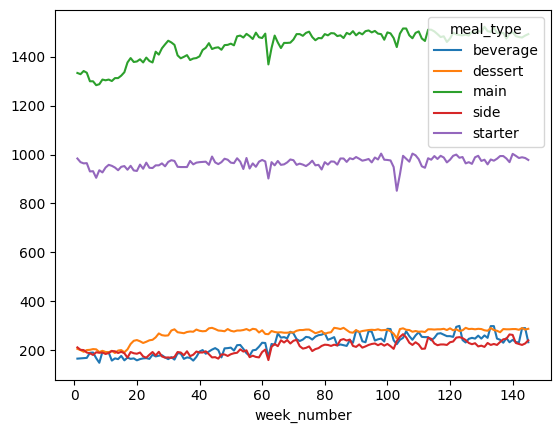

In [56]:
df.groupby(['meal_type', 'week_number']).size().unstack('meal_type').plot()

In [57]:
df.groupby(['city_name', 'week_number']).size().unstack('city_name')

city_name,Aldershade,Amberhill,Ashenport,Aspenfall,Brackenbury,Briarwood,Brightwater,Brookhollow,Candlekeep,Copperton,...,Vesperwood,Westfall,Willowgrove,Windridge,Winterhold,Xanadu,Yarrowford,Yewshade,Zarendale,Zephyrvale
week_number,,,,,,,,,,,,,,,,,,,,,
1,41.0,44.0,43.0,39.0,33.0,45.0,40.0,45.0,34.0,28.0,...,44.0,37.0,38.0,42.0,36.0,39.0,35.0,45.0,38.0,39.0
2,43.0,44.0,42.0,37.0,30.0,42.0,40.0,43.0,38.0,25.0,...,42.0,38.0,38.0,44.0,33.0,39.0,33.0,43.0,39.0,38.0
3,42.0,43.0,40.0,37.0,30.0,44.0,42.0,41.0,37.0,27.0,...,41.0,37.0,37.0,39.0,34.0,39.0,34.0,45.0,36.0,36.0
4,43.0,44.0,43.0,36.0,32.0,44.0,42.0,44.0,33.0,26.0,...,44.0,38.0,38.0,41.0,34.0,38.0,32.0,43.0,37.0,36.0
5,44.0,42.0,41.0,37.0,31.0,42.0,42.0,42.0,37.0,31.0,...,41.0,38.0,36.0,36.0,34.0,39.0,33.0,39.0,39.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,46.0,48.0,47.0,39.0,36.0,50.0,47.0,47.0,42.0,29.0,...,45.0,43.0,41.0,45.0,38.0,43.0,37.0,44.0,41.0,41.0
142,46.0,49.0,43.0,42.0,31.0,51.0,49.0,48.0,45.0,29.0,...,43.0,42.0,42.0,45.0,37.0,44.0,37.0,48.0,43.0,40.0
143,47.0,47.0,47.0,41.0,38.0,51.0,47.0,50.0,45.0,34.0,...,47.0,43.0,43.0,47.0,39.0,44.0,37.0,48.0,42.0,41.0


In [58]:
(df.groupby(['city_name', 'week_number']).size().unstack('city_name') == 0).sum().sum() ## this implies that in every city, ppl 
## tend to order every day of the week.

np.int64(0)

In [59]:
table = df.groupby(['city_name', 'week_number']).size().unstack('city_name')

In [60]:
table.loc[table.isna().any(axis=1)]

city_name,Aldershade,Amberhill,Ashenport,Aspenfall,Brackenbury,Briarwood,Brightwater,Brookhollow,Candlekeep,Copperton,...,Vesperwood,Westfall,Willowgrove,Windridge,Winterhold,Xanadu,Yarrowford,Yewshade,Zarendale,Zephyrvale
week_number,,,,,,,,,,,,,,,,,,,,,
5,44.0,42.0,41.0,37.0,31.0,42.0,42.0,42.0,37.0,31.0,...,41.0,38.0,36.0,36.0,34.0,39.0,33.0,39.0,39.0,38.0
6,43.0,40.0,38.0,37.0,33.0,43.0,44.0,43.0,36.0,28.0,...,38.0,36.0,38.0,41.0,34.0,38.0,32.0,43.0,36.0,34.0
7,42.0,43.0,38.0,38.0,29.0,44.0,41.0,43.0,35.0,27.0,...,41.0,35.0,38.0,39.0,29.0,39.0,32.0,38.0,35.0,32.0
8,44.0,41.0,35.0,37.0,28.0,43.0,42.0,43.0,37.0,26.0,...,40.0,37.0,38.0,36.0,33.0,37.0,36.0,43.0,37.0,35.0
9,45.0,44.0,38.0,37.0,32.0,45.0,44.0,43.0,37.0,31.0,...,39.0,36.0,38.0,36.0,37.0,37.0,36.0,41.0,39.0,36.0
10,44.0,41.0,40.0,38.0,33.0,42.0,41.0,44.0,38.0,29.0,...,41.0,37.0,38.0,38.0,32.0,39.0,38.0,38.0,40.0,38.0
11,44.0,42.0,39.0,36.0,27.0,44.0,41.0,45.0,38.0,29.0,...,40.0,35.0,34.0,43.0,37.0,38.0,35.0,41.0,42.0,38.0
12,43.0,44.0,35.0,39.0,29.0,45.0,42.0,43.0,36.0,26.0,...,42.0,37.0,38.0,41.0,31.0,39.0,34.0,39.0,41.0,37.0
13,44.0,44.0,40.0,38.0,28.0,44.0,41.0,44.0,34.0,28.0,...,41.0,38.0,37.0,37.0,32.0,39.0,36.0,45.0,38.0,38.0


In [61]:
(table.fillna(0) == 0).sum(axis=0).sort_values(ascending=False)

city_name
Osprey Point    25
Aldershade       0
Pinewatch        0
Silverstone      0
Ridgefield       0
                ..
Hollowcrest      0
Hawthorn         0
Harrowdale       0
Greenshade       0
Zephyrvale       0
Length: 77, dtype: int64

<Axes: xlabel='week_number'>

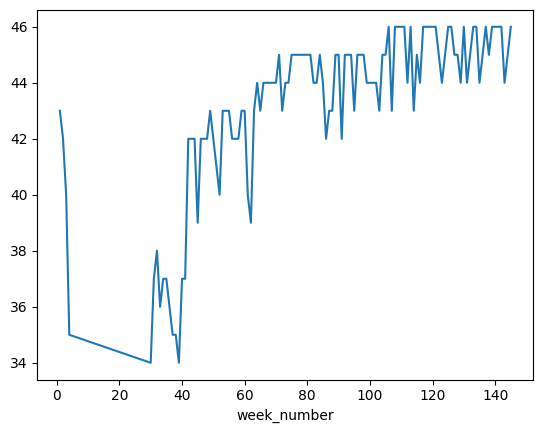

In [62]:
df[df['city_name']=='Osprey Point'].groupby('week_number').size().plot()

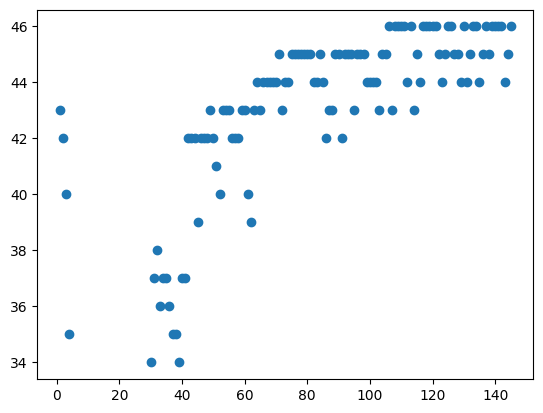

In [63]:
week_counts = df[df['city_name']=='Osprey Point'].groupby('week_number').size()

plt.scatter(week_counts.index, week_counts.values) ## the flat region above shows there is data missing 

<Axes: xlabel='week_number'>

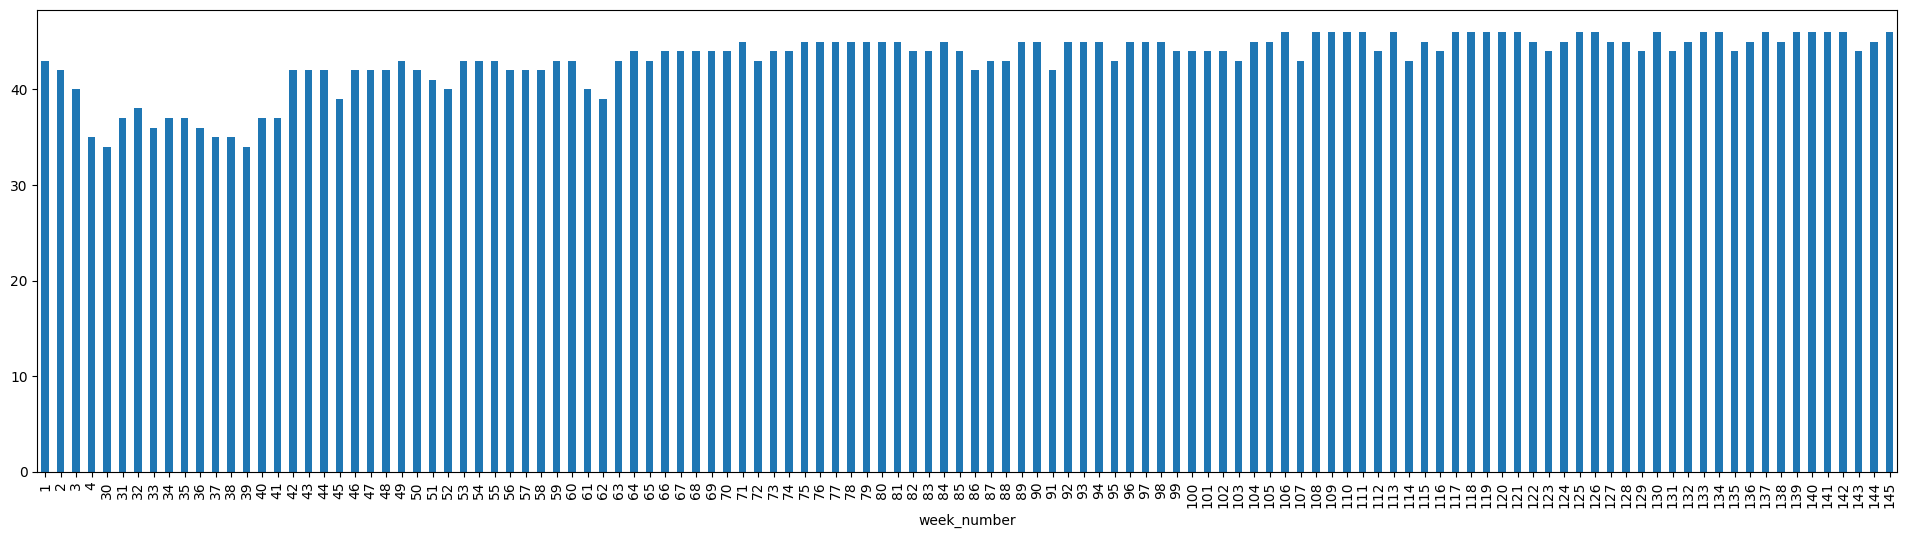

In [64]:
week_counts.plot(kind="bar", figsize=(24,6))

In [65]:
(df.groupby(['city_name', 'week_number']).num_orders.sum().unstack('city_name') < 5000).sum(axis=0).sort_values(ascending=False)

city_name
Elmswood        140
Fernwood        132
Nettlefield     122
Copperton       102
Kite's Nest      89
               ... 
Mirthwood         0
Oakhaven          0
Osprey Point      0
Quagmire          0
Zephyrvale        0
Length: 77, dtype: int64

In [66]:
(df['num_orders']==0).sum()

np.int64(0)

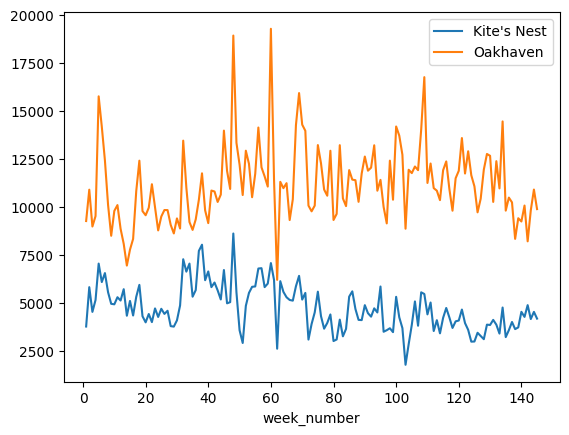

In [67]:
df[df['city_name']=="Kite's Nest"].groupby('week_number').num_orders.sum().plot(label="Kite's Nest")
df[df['city_name']=="Oakhaven"].groupby('week_number').num_orders.sum().plot(label="Oakhaven")

plt.legend()

In [68]:
## we are simply removing the missing data for 'Osprey Point' city. The other approach could be to perform interpolation.
def remove_low_coverage(df): 
    print(f"Length before removing low temporal coverage records: {len(df)}")
    df = df[~(df['city_name'] == 'Osprey Point')].copy()
    print(f"Length after removing low temporal coverage records: {len(df)}")
    return df
    

In [69]:
df = remove_low_coverage(df)

Length before removing low temporal coverage records: 451913
Length after removing low temporal coverage records: 446732


### Target Imbalance 

<Axes: >

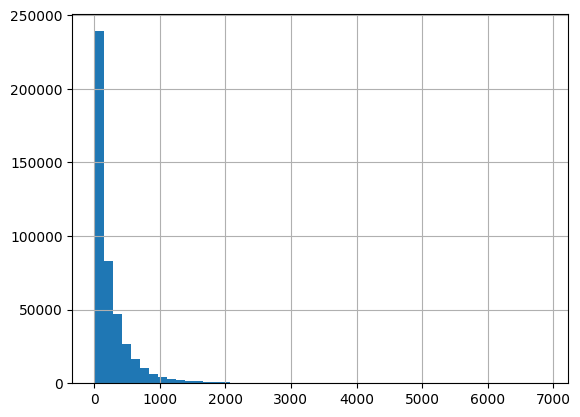

In [71]:
df.num_orders.hist(bins=50)


<Axes: >

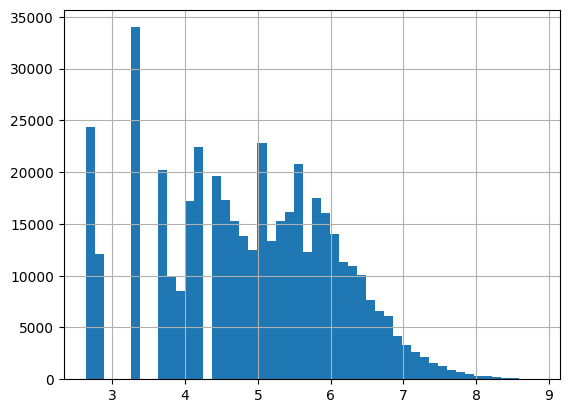

In [72]:
df.num_orders.apply(np.log1p).hist(bins=50)

### we could also design an error metric which would force the model to prioritize the higher order values.

In [74]:
df.emailer_for_promotion.value_counts()/len(df)

emailer_for_promotion
0    0.918851
1    0.081149
Name: count, dtype: float64

In [75]:
df.homepage_featured.value_counts()/len(df)

homepage_featured
0    0.890798
1    0.109202
Name: count, dtype: float64

In [76]:
df.city_name.value_counts()

city_name
Briarwood     6971
Greenshade    6952
Invermere     6922
Kingsholm     6874
Stormwatch    6840
              ... 
Harrowdale    4591
Pemberton     4447
Copperton     4326
Fernwood      4045
Elmswood      3397
Name: count, Length: 76, dtype: int64

In [77]:
df.meal_name.value_counts()

meal_name
Sage and Onion Porridge              10917
Fish and Chips                       10905
Spit-Roasted Quail                   10900
Beef and Ale Stew                    10893
Pumpkin Soup                         10893
Braised Oxen Tail                    10891
Baked Apple with Cinnamon            10875
Vegetable Stir-Fry                   10875
Dwarven Meat Pie                     10871
Mushroom Stew                        10855
Cheese and Onion Tart                10855
Garlic Roasted Potatoes              10843
Crab Cakes with Lemon Butter         10812
Pan-Seared Salmon                    10769
Spinach and Cheese Pastry            10735
Basil and Tomato Soup                10574
Wild Boar Ribs                       10536
Dwarven Ale Bread                    10523
Elven Salad with Nuts and Berries    10302
Grilled Trout with Lemon             10290
Dragonfire Chili                     10230
Fire-Grilled Venison                 10009
Salted Pork with Mustard              9994
V

In [78]:
df.meal_type.value_counts()

meal_type
main        207980
starter     138814
dessert      38161
beverage     31824
side         29953
Name: count, dtype: int64

### Visualize Time series data

In [80]:
s = df.groupby("week_number").num_orders.sum()

In [81]:
s

week_number
1      772831
2      764453
3      672482
4      721741
5      920320
        ...  
141    751091
142    712482
143    734884
144    776674
145    648256
Name: num_orders, Length: 145, dtype: int64

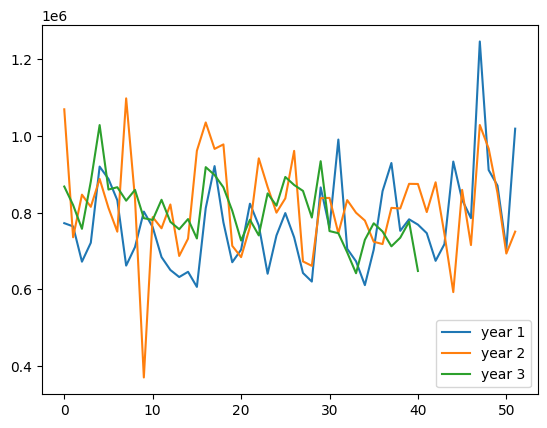

In [82]:
s[:52].reset_index(drop=True).plot(label="year 1")
s[52:104].reset_index(drop=True).plot(label="year 2")
s[104:].reset_index(drop=True).plot(label="year 3")

plt.legend()

### Distribution and normality analysis

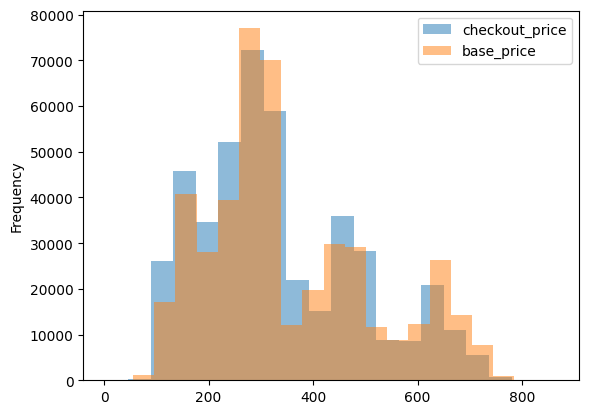

In [84]:
df.checkout_price.plot.hist(bins=20, alpha=0.5)
df.base_price.plot.hist(bins=20, alpha=0.5)
plt.legend()

### There are few city_meal combinations that have temporal gaps, which mean, that there are some weeks of data missing for them, 
### since they appeared in the data, upto the max time. There are several gaps. 

In [86]:
def gen_city_meal_with_temporal_gaps():
    for i, distinct in df[['city_name', 'meal_name']].drop_duplicates().sort_values(['city_name', 'meal_name']).iterrows():
        df_city_meals = df[(df['city_name'] == distinct.city_name) & (df['meal_name']== distinct.meal_name) ]
        min_week = df_city_meals.week_number.min()
        max_week = df_city_meals.week_number.max()
        if len(df_city_meals) == max_week - min_week + 1:
            continue
        else:
            yield {"city_name": distinct.city_name, "meal_name": distinct.meal_name}
        

In [87]:
value = gen_city_meal_with_temporal_gaps()

In [88]:
value.__next__()

{'city_name': 'Aldershade', 'meal_name': 'Apple and Raisin Bread'}

In [89]:
df.columns

Index(['week_number', 'checkout_price', 'base_price', 'emailer_for_promotion',
       'homepage_featured', 'num_orders', 'op_area', 'city_name', 'meal_name',
       'meal_category', 'meal_type'],
      dtype='object')

In [90]:
df.groupby(['city_name', 'meal_name']).week_number.count().reset_index().sort_values('week_number')

,city_name,meal_name,week_number
3522,Zephyrvale,Grilled Asparagus with Lemon,1
3515,Zephyrvale,Dwarven Stout,1
1516,Kestrelcliff,Grilled Asparagus with Lemon,1
1125,Harrowdale,Spicy Lamb Curry,3
2268,Pinewatch,Spicy Lamb Curry,3
...,...,...,...
1748,Lindenhurst,Fish and Chips,145
765,Everspring,Basil and Tomato Soup,145
1731,Lighthaven,Vegetable Stir-Fry,145
777,Everspring,Fish and Chips,145


In [91]:
df.groupby(['city_name', 'meal_name']).agg({'week_number': [len, 'min', 'max']})['week_number']

len  min  max
city_name  meal_name                                 
Aldershade Apple and Raisin Bread       118   27  145
           Baked Apple with Cinnamon    145    1  145
           Baked Potato with Chives     144    1  145
           Barley and Mushroom Risotto  134    1  145
           Basil and Tomato Soup        140    1  145
...                                     ...  ...  ...
Zephyrvale Spit-Roasted Quail           144    1  145
           Stuffed Mushrooms            129    1  145
           Vegetable Stir-Fry           145    1  145
           Venison Jerky                140    1  145
           Wild Boar Ribs               143    1  145

[3547 rows x 3 columns]

In [92]:
temporal_agg = df.groupby(['city_name', 'meal_name']).agg({'week_number': [len, 'min', 'max']})['week_number']

In [93]:
temporal_agg['week_range'] = temporal_agg['max'] - temporal_agg['min'] + 1

In [94]:
temporal_agg['temporal_issue'] = temporal_agg['len'] != temporal_agg['week_range']

In [95]:
temporal_agg

len  min  max  week_range  \
city_name  meal_name                                                
Aldershade Apple and Raisin Bread       118   27  145         119   
           Baked Apple with Cinnamon    145    1  145         145   
           Baked Potato with Chives     144    1  145         145   
           Barley and Mushroom Risotto  134    1  145         145   
           Basil and Tomato Soup        140    1  145         145   
...                                     ...  ...  ...         ...   
Zephyrvale Spit-Roasted Quail           144    1  145         145   
           Stuffed Mushrooms            129    1  145         145   
           Vegetable Stir-Fry           145    1  145         145   
           Venison Jerky                140    1  145         145   
           Wild Boar Ribs               143    1  145         145   

                                        temporal_issue  
city_name  meal_name                                    
Aldershade Apple and Raisin Bread                 True  
           Baked Apple with Cinnamon             False  
           Baked Potato with Chives               True  
           Barley and Mushroom Risotto            True  
           Basil and Tomato Soup                  True  
...                                                ...  
Zephyrvale Spit-Roasted Quail                     True  
           Stuffed Mushrooms                      True  
           Vegetable Stir-Fry                    False  
           Venison Jerky                          True  
           Wild Boar Ribs                         True  

[3547 rows x 5 columns]

In [204]:
temporal_agg[temporal_agg.temporal_issue == False].reset_index()

,city_name,meal_name,len,min,max,week_range,temporal_issue
0,Aldershade,Baked Apple with Cinnamon,145,1,145,145,False
1,Aldershade,Beef and Ale Stew,145,1,145,145,False
2,Aldershade,Garlic Roasted Potatoes,145,1,145,145,False
3,Aldershade,Herbed Rabbit Stew,122,24,145,122,False
4,Aldershade,Pan-Seared Salmon,145,1,145,145,False
...,...,...,...,...,...,...,...
330,Zephyrvale,Pan-Seared Salmon,145,1,145,145,False
331,Zephyrvale,Sage and Onion Porridge,145,1,145,145,False
332,Zephyrvale,Savory Meat Pies,129,17,145,129,False
333,Zephyrvale,Spinach and Cheese Pastry,145,1,145,145,False


In [96]:
for i, record in temporal_agg[temporal_agg.temporal_issue].sample(10).iterrows():
    print(record.name)

('Nettlefield', 'Beef and Ale Stew')
('Quicksilver', 'Venison Jerky')
('Oakenspire', 'Forest Berry Pie')
('Willowgrove', 'Herb-Crusted Lamb')
('Aspenfall', 'Dragonfire Chili')
('Driftwood', 'Wild Berry Cobbler')
('Brookhollow', 'Dwarven Meat Pie')
('Thornfield', 'Goat Cheese and Spinach Salad')
('Duskbrook', 'Grilled Asparagus with Lemon')
('Jasperwood', 'Dwarven Meat Pie')


Missing weeks for ('Kingsholm', 'Sage and Onion Porridge'): [  3  17 135]


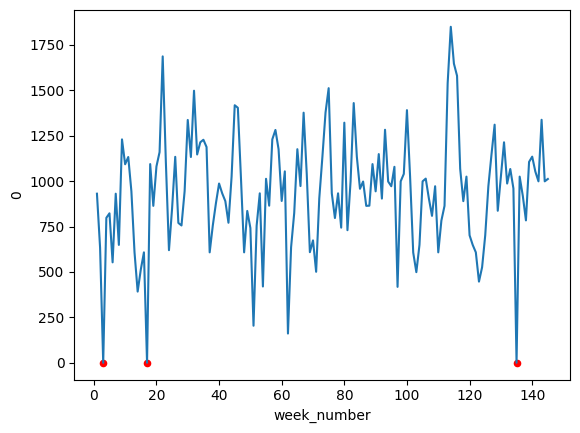

In [97]:
for i, record in temporal_agg[temporal_agg.temporal_issue].iterrows():
    if (record.name[0] == 'Kingsholm') & (record.name[1] == 'Sage and Onion Porridge'):
        df_city_meal = df[(df.city_name == record.name[0]) & (df.meal_name == record.name[1])].copy()
        df_missing_weeks = pd.DataFrame(list(range(df_city_meal.week_number.min(), df_city_meal.week_number.max()+1)), columns=['week_number'])
    
        df_city_meal = pd.merge(
            df_city_meal,
            df_missing_weeks,
            on='week_number',
            how='outer'
        )
    
        
        print(f"Missing weeks for {record.name}: {df_city_meal[df_city_meal.num_orders.isnull()].week_number.sort_values().values}")

        ax = df_city_meal.groupby("week_number").num_orders.sum().plot()
        (df_city_meal[df_city_meal.num_orders.isnull()].groupby("week_number").size()).reset_index().plot.scatter(x='week_number', y=0, ax=ax, c='red')
        plt.show()

In [98]:
df_missing_weeks = pd.DataFrame(list(range(1, 145+1)), columns=['week_number'])

df_city_meal = pd.merge(
                        df_city_meal,
                        df_missing_weeks,
                        on='week_number',
                        how='outer'
                        )



In [99]:
df_city_meal.iloc[:20, :]

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type
0,1,183.36,184.36,0.0,0.0,931.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
1,2,184.36,184.36,0.0,0.0,634.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,183.36,182.36,0.0,0.0,798.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
4,5,181.39,181.39,0.0,0.0,823.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
5,6,162.05,183.39,0.0,0.0,553.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
6,7,160.11,183.39,0.0,0.0,931.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
7,8,156.17,181.39,0.0,0.0,649.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
8,9,162.05,182.39,0.0,0.0,1230.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
9,10,161.05,183.39,0.0,0.0,1093.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter


In [100]:
df_city_meal['num_orders'] = df_city_meal['num_orders'].fillna(0)
df_city_meal = df_city_meal.ffill()

In [101]:
df_city_meal.iloc[:20, :]

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type
0,1,183.36,184.36,0.0,0.0,931.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
1,2,184.36,184.36,0.0,0.0,634.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
2,3,184.36,184.36,0.0,0.0,0.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
3,4,183.36,182.36,0.0,0.0,798.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
4,5,181.39,181.39,0.0,0.0,823.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
5,6,162.05,183.39,0.0,0.0,553.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
6,7,160.11,183.39,0.0,0.0,931.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
7,8,156.17,181.39,0.0,0.0,649.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
8,9,162.05,182.39,0.0,0.0,1230.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter
9,10,161.05,183.39,0.0,0.0,1093.0,5.1,Kingsholm,Sage and Onion Porridge,Vegetarian,starter


In [102]:
from tqdm.notebook import tqdm

In [194]:
city_meal_dfs = []
for i, record in tqdm(df[['city_name', 'meal_name']].drop_duplicates().sort_values(['city_name', 'meal_name']).iterrows(), total=3547):
    
    df_city_meal = df[(df.city_name == record.city_name) & (df.meal_name == record.meal_name)].copy()
    df_missing_weeks = pd.DataFrame(list(range(df_city_meal.week_number.min(), df_city_meal.week_number.max()+1)), columns=['week_number'])

    df_city_meal = pd.merge(
        df_city_meal,
        df_missing_weeks,
        on='week_number',
        how='outer'
    )

    df_city_meal['num_orders'] = df_city_meal.num_orders.fillna(0)
    df_city_meal = df_city_meal.sort_values("week_number")
    df_city_meal = df_city_meal.ffill()
    city_meal_dfs.append(df_city_meal)

df_fixed = pd.concat(city_meal_dfs)


0it [00:00, ?it/s]

In [196]:
df_fixed

,week_number,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,op_area,city_name,meal_name,meal_category,meal_type
0,27,136.83,135.83,0.0,0.0,256.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
1,28,332.71,332.71,0.0,0.0,122.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
2,29,332.71,332.71,0.0,0.0,163.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
3,30,334.71,333.71,0.0,0.0,284.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
4,31,332.71,333.71,0.0,0.0,189.0,3.7,Aldershade,Apple and Raisin Bread,Other,dessert
...,...,...,...,...,...,...,...,...,...,...,...
140,141,360.84,362.84,0.0,0.0,148.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main
141,142,368.63,369.63,0.0,0.0,162.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main
142,143,358.93,357.93,0.0,0.0,176.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main
143,144,359.90,358.90,0.0,0.0,108.0,3.9,Zephyrvale,Wild Boar Ribs,Meat,main


In [198]:
len(df)

446732